In [1]:
import numpy as np
import torch
import scipy.io as sio
from sklearn.decomposition import SparseCoder, MiniBatchDictionaryLearning
from torch import nn
from DL import DL
import time 
import matplotlib.pyplot as plt

In [2]:
def patch2d(A,l1=8,l2=8,s1=4,s2=4,mode=1):
	"""
	patch2d: decompose the image into patches:
	
	INPUT
	D: input image
	l1: first patch size
	l2: second patch size
	s1: first shifting size
	s2: second shifting size
	mode: patching mode
	
	OUTPUT
	X: patches
	
	HISTORY
	by Yangkang Chen
	Oct, 2017
	Modified on Dec 12, 2018 (the edge issue, arbitrary size for the matrix)
			 Dec 31, 2018 (tmp1=mod(n1,l1) -> tmp1=mod(n1-l1,s1))
	
	EXAMPLE 1
	
	#generate data
	from pyseistr import gensyn
	data,noisy=gensyn(noise=True);[n1,n2]=data.shape;
	import matplotlib.pyplot as plt;
	plt.subplot(1,2,1);plt.imshow(data,clim=[-0.2,0.2],aspect='auto');plt.xlabel('Trace');plt.ylabel('Time sample');
	plt.subplot(1,2,2);plt.imshow(noisy,clim=[-0.2,0.2],aspect='auto');plt.xlabel('Trace');
	plt.show();
	
	from pyseistr import patch2d
	X=patch2d(data,l1=16,l2=16,s1=8,s2=8);

	#visualize the patches
	from pyseistr import cseis
	plt.imshow(X,aspect='auto',cmap=cseis());plt.ylabel('Patch NO');plt.xlabel('Patch Pixel');plt.show()
	plt.figure(figsize=(8,8))
	for ii in range(64):
		ax=plt.subplot(8,8,ii+1)
		plt.imshow(X[3200+ii,:].reshape(16,16,order='F'),cmap=cseis(),clim=(-0.5,0.5),aspect='auto');
		plt.setp(ax.get_xticklabels(), visible=False);plt.setp(ax.get_yticklabels(), visible=False);
	plt.show()

	#reconstruct
	from pyseistr import patch2d_inv
	import numpy as np
	data2=patch2d_inv(X,n1,n2,l1=16,l2=16,s1=8,s2=8);
	print('Error=',np.linalg.norm(data.flatten()-data2.flatten()))
	
	plt.figure(figsize=(16,8));
	plt.imshow(np.concatenate([data,data2,data-data2],axis=1),aspect='auto');
	plt.show()

	EXAMPLE 2
	https://github.com/chenyk1990/mlnb/blob/main/DL_denoise_simple2D.ipynb
	
	EXAMPLE 3
	sgk_denoise() in pyseisdl/denoise.py
	"""
	[n1,n2]=A.shape;

	if mode==1: 	#possible for other patching options
		
		tmp=np.mod(n1-l1,s1);
		if tmp!=0:
			A=np.concatenate((A,np.zeros([s1-tmp,n2])),axis=0); 
		tmp=np.mod(n2-l2,s2);
		if tmp!=0:
			A=np.concatenate((A,np.zeros([A.shape[0],s2-tmp])),axis=1); 
		
		[N1,N2]=A.shape;
		X=[]
		for i1 in range(0,N1-l1+1,s1):
			for i2 in range(0,N2-l2+1,s2):
						tmp=np.reshape(A[i1:i1+l1,i2:i2+l2],(l1*l2,1),order='F');
						X.append(tmp)
		X = np.array(X)
	else:
		#not written yet
		pass;
	return X[:,:,0]



def patch2d_inv(X,n1,n2,l1=8,l2=8,s1=4,s2=4,mode=1):
	"""
	patch2d_inv: insert patches into the image
	
	INPUT
	D: input patches (sample,patchsize)
	mode: patching mode
	l1: first patch size
	l2: second patch size
	s1: first shifting size
	s2: second shifting size
	
	OUTPUT
	X: patches
	
	HISTORY
	by Yangkang Chen
	Oct, 2017
	Modified on Dec 12, 2018 (the edge issue, arbitrary size for the matrix)
				Dec 31, 2018 (tmp1=mod(n1,l1) -> tmp1=mod(n1-l1,s1))
	
	EXAMPLE 1
	
	#generate data
	from pyseistr import gensyn
	data,noisy=gensyn(noise=True);[n1,n2]=data.shape;
	import matplotlib.pyplot as plt;
	plt.subplot(1,2,1);plt.imshow(data,clim=[-0.2,0.2],aspect='auto');plt.xlabel('Trace');plt.ylabel('Time sample');
	plt.subplot(1,2,2);plt.imshow(noisy,clim=[-0.2,0.2],aspect='auto');plt.xlabel('Trace');
	plt.show();
	
	from pyseistr import patch2d
	X=patch2d(data,l1=16,l2=16,s1=8,s2=8);

	#visualize the patches
	from pyseistr import cseis
	plt.imshow(X,aspect='auto',cmap=cseis());plt.ylabel('Patch NO');plt.xlabel('Patch Pixel');plt.show()
	plt.figure(figsize=(8,8))
	for ii in range(64):
		ax=plt.subplot(8,8,ii+1)
		plt.imshow(X[3200+ii,:].reshape(16,16,order='F'),cmap=cseis(),clim=(-0.5,0.5),aspect='auto');
		plt.setp(ax.get_xticklabels(), visible=False);plt.setp(ax.get_yticklabels(), visible=False);
	plt.show()

	#reconstruct
	from pyseistr import patch2d_inv
	import numpy as np
	data2=patch2d_inv(X,n1,n2,l1=16,l2=16,s1=8,s2=8);
	print('Error=',np.linalg.norm(data.flatten()-data2.flatten()))
	
	plt.figure(figsize=(16,8));
	plt.imshow(np.concatenate([data,data2,data-data2],axis=1),aspect='auto');
	plt.show()

	EXAMPLE 2
	https://github.com/chenyk1990/mlnb/blob/main/DL_denoise_simple3D.ipynb
	
	EXAMPLE 3
	sgk_denoise() in pyseisdl/denoise.py

	"""

	if mode==1: 	#possible for other patching options

		tmp1=np.mod(n1-l1,s1);
		tmp2=np.mod(n2-l2,s2);
		if tmp1!=0 and tmp2!=0:
			A=np.zeros([n1+s1-tmp1,n2+s2-tmp2]); 
			mask=np.zeros([n1+s1-tmp1,n2+s2-tmp2]); 

		if tmp1!=0 and tmp2==0:
			A=np.zeros([n1+s1-tmp1,n2]); 
			mask=np.zeros([n1+s1-tmp1,n2]);

		if tmp1==0 and tmp2!=0:
			A=np.zeros([n1,n2+s2-tmp2]);   
			mask=np.zeros([n1,n2+s2-tmp2]);   


		if tmp1==0 and tmp2==0:
			A=np.zeros([n1,n2]); 
			mask=np.zeros([n1,n2]);

		[N1,N2]=A.shape;
		id=-1;
		for i1 in range(0,N1-l1+1,s1):
			for i2 in range(0,N2-l2+1,s2):
				id=id+1;
				A[i1:i1+l1,i2:i2+l2]=A[i1:i1+l1,i2:i2+l2]+np.reshape(X[id,:],[l1,l2],order='F');
				mask[i1:i1+l1,i2:i2+l2]=mask[i1:i1+l1,i2:i2+l2]+np.ones([l1,l2]);

		A=A/mask; 
		A=A[0:n1,0:n2];
	else:
		#not written yet
		pass;
	return A

In [5]:
# 1. 加载数据
seismic = sio.loadmat('real2d.mat')
#Dc = seismic['DataClean'].astype(np.float32)   # 干净数据
Dn = seismic['Dn'].astype(np.float32)   # 含噪数据
mask = np.ones_like(Dn)
d0 = Dn * mask
n1, n2 = Dn.shape

In [6]:
nz = Dn.shape[0]  # 对应MATLAB：n1 = size(Dn, 1)
nx = Dn.shape[1]  # 对应MATLAB：n2 = size(Dn, 2)

In [7]:
def calculate_snr(clean_data, denoised_data):
    # 确保输入是一维向量，或者直接不带 ord 参数（默认就是 Frobenius 范数，即全图能量）
    norm_clean = np.linalg.norm(clean_data)  # 默认计算所有元素的平方和开根号
    norm_diff = np.linalg.norm(clean_data - denoised_data)
    
    snr = 20 * np.log10(norm_clean / norm_diff)
    return snr

In [8]:
#snr_before = calculate_snr(Dc, Dn)
#print(f"去噪前 SNR: {snr_before:.2f} dB")

In [9]:
# 2. 设置分块参数（按照您要求的格式）
w1 = 32
w2 = 32
s1 = 1  # 步长建议根据数据量调整，s=1会导致Patch数量极大
s2 = 1
input_size = w1 * w2
# 3. 初始化网络与优化器
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
net = DL(input_size).to(device)
optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

In [10]:
niter = 10
epochs_per_iter = 20
alpha_list = (niter - np.arange(niter)) / (niter - 1)
d1 = Dn.copy()

In [11]:
total_start_time = time.time()
all_loss_history = []
for it in range(niter):
    iter_start_time = time.time()
    print(f"\n===== 2D DDIUL 迭代 {it + 1}/{niter} =====")
    
    # --- 分块操作 ---
    X = patch2d(d1, w1, w2, s1, s2)
    X = X.astype(np.float32)
    Pdata = torch.from_numpy(X)
    # 【新增：查看总规模】
    print(f"-> 分块后的总补丁数 (Total Patches): {X.shape[0]}")
    
    # --- REBPS 补丁筛选 (基于最新 scikit-learn 修正 max_iter) ---
    dl_learner = MiniBatchDictionaryLearning(n_components=512, alpha=1, max_iter=50)
    dictionary = dl_learner.fit(X).components_
    coder = SparseCoder(dictionary=dictionary, transform_algorithm='omp', transform_n_nonzero_coefs=10)
    error = np.linalg.norm(X - np.dot(coder.transform(X), dictionary), axis=1)
    
    selected_idx = np.argsort(error)[-int(len(X) * 0.75):]
    train_tensor = Pdata[selected_idx].unsqueeze(1).to(device)
    # 【新增：查看筛选后规模】
    print(f"-> REBPS 筛选后的训练补丁数: {len(selected_idx)}")
    
    # --- 模型初始化与训练 ---
    net = DL(w1*w2).to(device) # 确保每次大迭代可以重新学习或微调
    optimizer = torch.optim.Adam(net.parameters(), lr=0.001)
    
    iter_loss = []
    best_loss = float('inf')
    patience_counter = 0
    patience = 5  # 如果连续5个epoch损失不下降则触发早停
    
    net.train()
    loader = torch.utils.data.DataLoader(train_tensor, batch_size=256, shuffle=True)
    
    for epoch in range(epochs_per_iter):
        epoch_loss = 0.0
        for batch in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            output = net(batch)
            loss = loss_fn(output, batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        avg_epoch_loss = epoch_loss / len(loader)
        iter_loss.append(avg_epoch_loss)
        
        # 早停逻辑判断
        if avg_epoch_loss < best_loss:
            best_loss = avg_epoch_loss
            patience_counter = 0
        else:
            patience_counter += 1
            
        if (epoch + 1) % 5 == 0:
            print(f"Epoch [{epoch+1}/{epochs_per_iter}], Loss: {avg_epoch_loss:.6f}")
            
        if patience_counter >= patience:
            print(f"--> Early Stopping triggered at epoch {epoch+1}")
            break
            
    all_loss_history.append(iter_loss)
    
    # --- 推理与 POCS 重构 ---
    net.eval()
    with torch.no_grad():
        all_p = Pdata.unsqueeze(1).to(device)
        recon_X = torch.cat([net(all_p[i:i+1024]) for i in range(0, len(all_p), 1024)])
        recon_X = recon_X.cpu().squeeze().numpy()
    
    d2 = patch2d_inv(recon_X, nz, nx, w1, w2, s1, s2)
    d1 = alpha_list[it] * Dn + (1 - alpha_list[it]) * d2
    
    iter_end_time = time.time()
    print(f"本轮迭代耗时: {iter_end_time - iter_start_time:.2f} 秒")

total_end_time = time.time()
print(f"\n[完成] 总运行时间: {(total_end_time - total_start_time)/60:.2f} 分钟")


===== 2D DDIUL 迭代 1/10 =====
-> 分块后的总补丁数 (Total Patches): 44252
-> REBPS 筛选后的训练补丁数: 33189
Epoch [5/20], Loss: 0.113593
Epoch [10/20], Loss: 0.105306
Epoch [15/20], Loss: 0.101532
Epoch [20/20], Loss: 0.099177
本轮迭代耗时: 465.29 秒

===== 2D DDIUL 迭代 2/10 =====
-> 分块后的总补丁数 (Total Patches): 44252
-> REBPS 筛选后的训练补丁数: 33189
Epoch [5/20], Loss: 0.134890
Epoch [10/20], Loss: 0.125269
Epoch [15/20], Loss: 0.121103
Epoch [20/20], Loss: 0.118695
本轮迭代耗时: 517.57 秒

===== 2D DDIUL 迭代 3/10 =====
-> 分块后的总补丁数 (Total Patches): 44252
-> REBPS 筛选后的训练补丁数: 33189
Epoch [5/20], Loss: 0.114980
Epoch [10/20], Loss: 0.106674
Epoch [15/20], Loss: 0.102526
Epoch [20/20], Loss: 0.100007
本轮迭代耗时: 470.92 秒

===== 2D DDIUL 迭代 4/10 =====
-> 分块后的总补丁数 (Total Patches): 44252
-> REBPS 筛选后的训练补丁数: 33189
Epoch [5/20], Loss: 0.097078
Epoch [10/20], Loss: 0.089832
Epoch [15/20], Loss: 0.086611
Epoch [20/20], Loss: 0.084126
本轮迭代耗时: 461.94 秒

===== 2D DDIUL 迭代 5/10 =====
-> 分块后的总补丁数 (Total Patches): 44252
-> REBPS 筛选后的训练补丁数: 33189
E

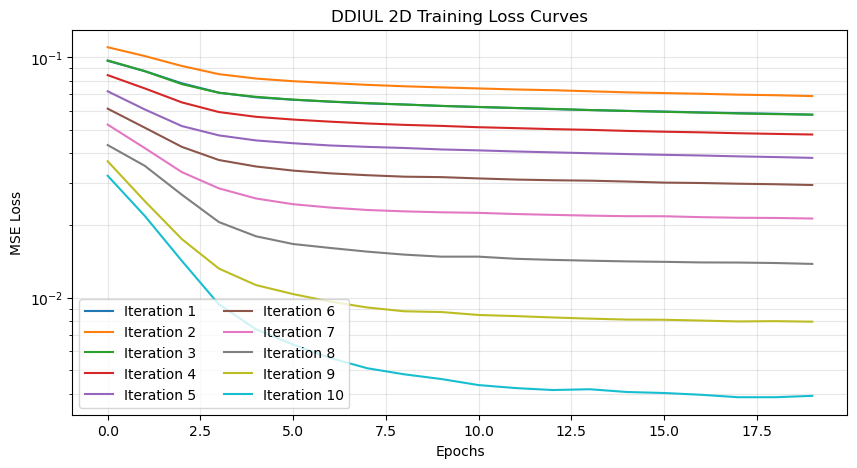

In [33]:
# --- 损失曲线可视化 ---
plt.figure(figsize=(10, 5))
for i, losses in enumerate(all_loss_history):
    plt.plot(losses, label=f'Iteration {i+1}')
plt.title('DDIUL 2D Training Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.yscale('log')
plt.legend(ncol=2)
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [12]:
sio.savemat(r"output_real2d1.mat", {'D_denoised': d1})

In [34]:
# 4. 结果评估与保存
snr_after = calculate_snr(Dc, d1)
snr_imp = snr_after - snr_before

print("\n" + "="*30)
print(f"2D 去噪完成！")
print(f"去噪前 SNR: {snr_before:.2f} dB")
print(f"去噪后 SNR: {snr_after:.2f} dB")
print(f"SNR 提升值: {snr_imp:.2f} dB")
print("="*30)

# 仅保存去噪结果
sio.savemat(r"output_syn2dDD.mat", {'D_denoised': d1})


2D 去噪完成！
去噪前 SNR: -4.27 dB
去噪后 SNR: 10.61 dB
SNR 提升值: 14.88 dB


In [19]:
sio.savemat(r"output_syn2d.mat", {'D_denoised': d1})


2D 去噪完成！
去噪前 SNR: -4.27 dB
去噪后 SNR: 8.02 dB
SNR 提升值: 12.28 dB


In [13]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()  # 清理进程间显存缓存，进一步减少碎片